In [2]:
import torch
from base_model import *
from utils import *
from custom_layer import *

In [3]:
torch.backends.mkldnn.enabled = True

In [4]:
train_dataset, val_dataset = get_dataset()
criterion = torch.nn.CrossEntropyLoss()

In [5]:
block0 = nn.Sequential(
    nn.BatchNorm2d(3),#Not normal to use batchnorm at the beginning of the network, but based on empirical results, it can improve the performance of small model
    nn.Conv2d(3, 30, 3, padding=1, groups=3),
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 3, padding=1, groups=30),
    nn.BatchNorm2d(30),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 32 → 16

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),
)
block1 = nn.Sequential(
    # -------- Block 2 --------
    nn.Conv2d(30, 60, 3, padding=1,groups=30),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1,groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 16 → 8

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),
)
block2 = nn.Sequential(
    # -------- Block 3 --------
    nn.Conv2d(60, 30, 3, padding=1, groups=30),
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 60, 3, padding=1, groups=30),
    nn.BatchNorm2d(60),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 8 → 4

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),
)
block3 = nn.Sequential(
    # -------- Block 4 --------
    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    # nn.Conv2d(60, 60, 1),   # pointwise conv
    # nn.BatchNorm2d(60),
    # nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 4 → 2

    # nn.Conv2d(60, 60, 1),   # pointwise conv
    # nn.BatchNorm2d(60),
    # nn.PReLU(),
)

classifier = nn.Sequential(
    nn.Flatten(),
    nn.Linear(240, 10)
)

In [6]:
model35_0 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model35_0)
describe(model35_0)

MACs: 4.25 MMac, Params: 21.69 k
Layer (type:depth-idx)                   Output Shape              Param #
BaseModelF32                             [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                  [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-8                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-10                  [1, 30, 32,

Loading checkpoint from model_weights/model35_0.pt
Starting
Epoch 1/60: Train loss = 1.1934, Train accuracy = 0.5712, Test loss = 1.1693, Test accuracy = 0.5780
Epoch 2/60: Train loss = 0.9490, Train accuracy = 0.6617, Test loss = 0.8829, Test accuracy = 0.6852
Epoch 3/60: Train loss = 0.8635, Train accuracy = 0.6955, Test loss = 0.8353, Test accuracy = 0.7062
Epoch 4/60: Train loss = 0.7804, Train accuracy = 0.7277, Test loss = 0.7745, Test accuracy = 0.7343
Epoch 5/60: Train loss = 0.7722, Train accuracy = 0.7348, Test loss = 0.7692, Test accuracy = 0.7405
Epoch 6/60: Train loss = 0.7091, Train accuracy = 0.7508, Test loss = 0.7215, Test accuracy = 0.7520
Epoch 7/60: Train loss = 0.6911, Train accuracy = 0.7579, Test loss = 0.7021, Test accuracy = 0.7615
Epoch 8/60: Train loss = 0.6861, Train accuracy = 0.7604, Test loss = 0.7094, Test accuracy = 0.7527
Epoch 9/60: Train loss = 0.6228, Train accuracy = 0.7835, Test loss = 0.6357, Test accuracy = 0.7784
Epoch 10/60: Train loss = 0.646

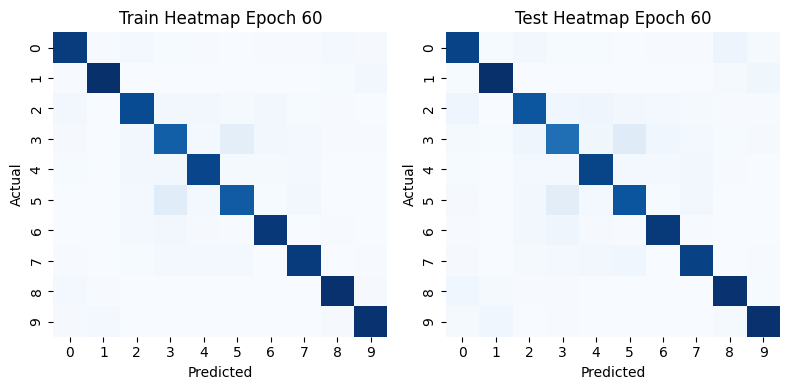

<Figure size 1200x600 with 0 Axes>

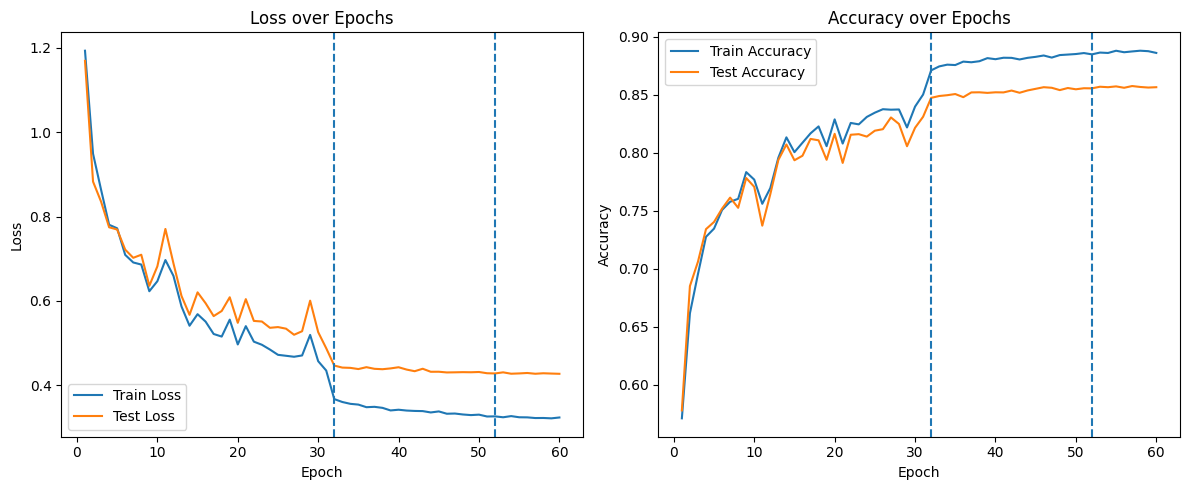

In [7]:
trainf32(model35_0,"model_weights/model35_0.pt",criterion,train_dataset,val_dataset, batch_size=128)

In [8]:
model35_1 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model35_1)
describe(model35_1)

MACs: 4.25 MMac, Params: 21.69 k
Layer (type:depth-idx)                   Output Shape              Param #
BaseModelF32                             [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                  [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-8                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-10                  [1, 30, 32,

Loading checkpoint from model_weights/model35_1.pt
Starting
Epoch 1/60: Train loss = 1.0088, Train accuracy = 0.6350, Test loss = 0.9954, Test accuracy = 0.6450
Epoch 2/60: Train loss = 0.8189, Train accuracy = 0.7111, Test loss = 0.7982, Test accuracy = 0.7229
Epoch 3/60: Train loss = 0.8130, Train accuracy = 0.7193, Test loss = 0.7990, Test accuracy = 0.7249
Epoch 4/60: Train loss = 0.8076, Train accuracy = 0.7217, Test loss = 0.8004, Test accuracy = 0.7323
Epoch 5/60: Train loss = 0.6739, Train accuracy = 0.7632, Test loss = 0.6788, Test accuracy = 0.7621
Epoch 6/60: Train loss = 0.6778, Train accuracy = 0.7635, Test loss = 0.6610, Test accuracy = 0.7719
Epoch 7/60: Train loss = 0.6447, Train accuracy = 0.7739, Test loss = 0.6822, Test accuracy = 0.7680
Epoch 8/60: Train loss = 0.6121, Train accuracy = 0.7881, Test loss = 0.6409, Test accuracy = 0.7885
Epoch 9/60: Train loss = 0.6371, Train accuracy = 0.7769, Test loss = 0.6577, Test accuracy = 0.7732
Epoch 10/60: Train loss = 0.576

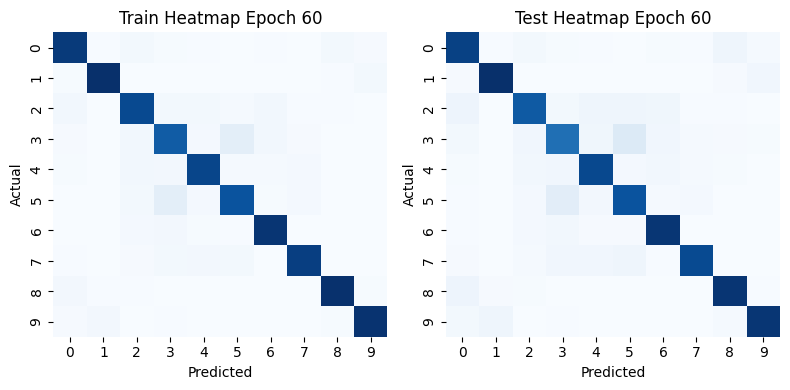

<Figure size 1200x600 with 0 Axes>

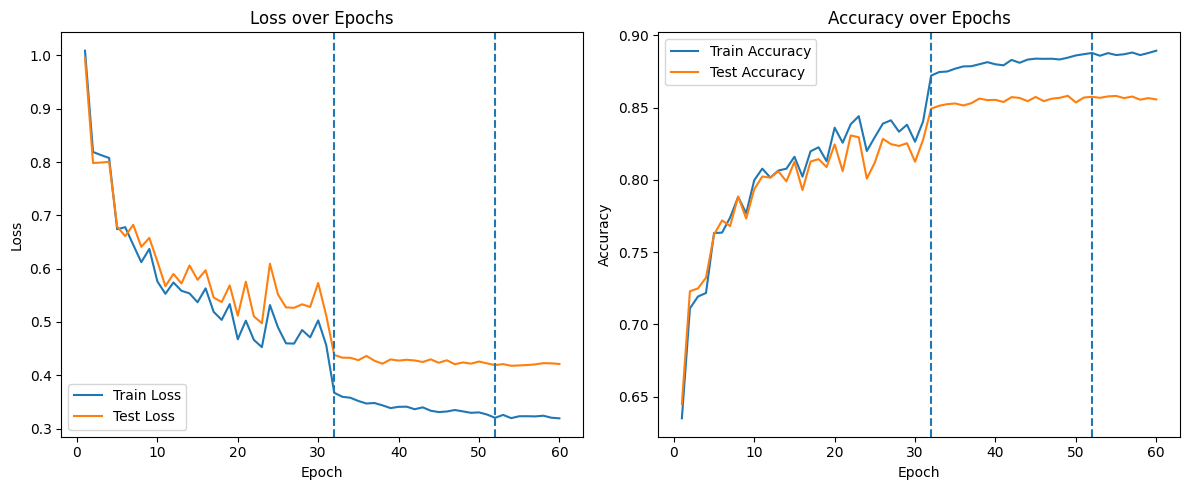

In [9]:
trainf32(model35_1,"model_weights/model35_1.pt",criterion,train_dataset,val_dataset, batch_size=64)